In [ ]:
#prep
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import shap
from sklearn.model_selection import GroupKFold

In [33]:
#load walkability data

walk = pd.read_csv('Walkability_Index.csv')

print(walk.head())

   OBJECTID  TRACT00   TRACT  Walkability   Shape__Area  Shape__Length
0         1   101110  101110    -2.441735  1.229550e+07   15083.490095
1         2   101122  101122    -5.011306  2.637831e+07   30895.536646
2         3   101210  101210     1.396715  7.002749e+06   12066.880686
3         4   101220  101220    -0.086782  7.523373e+06   12697.819097
4         5   101300  101300    -3.158726  2.774817e+07   29295.933607


In [35]:
#load census data

census = pd.read_csv('census/acs2023data.csv', low_memory=False)

print(census.head())

                 GEO_ID                                               NAME  \
0             Geography                               Geographic Area Name   
1        0500000US06037                     Los Angeles County, California   
2  1400000US06037101110  Census Tract 1011.10; Los Angeles County; Cali...   
3  1400000US06037101122  Census Tract 1011.22; Los Angeles County; Cali...   
4  1400000US06037101220  Census Tract 1012.20; Los Angeles County; Cali...   

                                DP05_0001E  \
0  Estimate!!SEX AND AGE!!Total population   
1                                  9848406   
2                                     4152   
3                                     4198   
4                                     3434   

                                       DP05_0001M  \
0  Margin of Error!!SEX AND AGE!!Total population   
1                                           *****   
2                                             441   
3                                         

In [37]:
#load income data
income  = pd.read_csv('census/income2023.csv', low_memory=False)

print(income.head())

        tract  med_hh_income  med_hh_income_universe     ami_category  \
0  6037101110        84091.0                    1558       Low Income   
1  6037101122        99583.0                    1407       Low Income   
2  6037101220        69676.0                    1357       Low Income   
3  6037101221        53798.0                    1483  Very Low Income   
4  6037101222        45662.0                     948  Very Low Income   

  below_med_income below_60pct_med_income below_moderate_income    sup_dist  \
0              Yes                     No                   Yes  District 5   
1               No                     No                   Yes  District 5   
2              Yes                    Yes                   Yes  District 5   
3              Yes                    Yes                   Yes  District 5   
4              Yes                    Yes                   Yes  District 5   

                     csa                   spa  ESRI_OID   Shape__Area  \
0  Los Angel

In [39]:
walk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OBJECTID       1003 non-null   int64  
 1   TRACT00        1003 non-null   int64  
 2   TRACT          1003 non-null   int64  
 3   Walkability    1003 non-null   float64
 4   Shape__Area    1003 non-null   float64
 5   Shape__Length  1003 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.1 KB


In [41]:
census.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Columns: 379 entries, GEO_ID to Unnamed: 378
dtypes: float64(1), object(378)
memory usage: 7.2+ MB


In [43]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tract                   2495 non-null   int64  
 1   med_hh_income           2453 non-null   float64
 2   med_hh_income_universe  2495 non-null   int64  
 3   ami_category            2453 non-null   object 
 4   below_med_income        2453 non-null   object 
 5   below_60pct_med_income  2453 non-null   object 
 6   below_moderate_income   2453 non-null   object 
 7   sup_dist                2495 non-null   object 
 8   csa                     2495 non-null   object 
 9   spa                     2495 non-null   object 
 10  ESRI_OID                2495 non-null   int64  
 11  Shape__Area             2495 non-null   float64
 12  Shape__Length           2495 non-null   float64
dtypes: float64(3), int64(3), object(7)
memory usage: 253.5+ KB


In [45]:
#create another column in df_census that is tract00 that takes the last 6 digits of geo_id 
census['TRACT00'] = census['GEO_ID'].str[-6:]

print(census[['GEO_ID', 'TRACT00']].head())

                 GEO_ID TRACT00
0             Geography  graphy
1        0500000US06037  S06037
2  1400000US06037101110  101110
3  1400000US06037101122  101122
4  1400000US06037101220  101220


In [47]:
#same for income
#convert to string
income['tract'] = income['tract'].astype(str)


income['TRACT00'] = income['tract'].str[-6:]

print(income[['tract', 'TRACT00']].head())

        tract TRACT00
0  6037101110  101110
1  6037101122  101122
2  6037101220  101220
3  6037101221  101221
4  6037101222  101222


In [51]:
#merge data
merged = pd.merge(walk, census, how='left', on='TRACT00')

print(merged.head())

   OBJECTID TRACT00   TRACT  Walkability   Shape__Area  Shape__Length  \
0         1  101110  101110    -2.441735  1.229550e+07   15083.490095   
1         2  101122  101122    -5.011306  2.637831e+07   30895.536646   
2         3  101210  101210     1.396715  7.002749e+06   12066.880686   
3         4  101220  101220    -0.086782  7.523373e+06   12697.819097   
4         5  101300  101300    -3.158726  2.774817e+07   29295.933607   

                 GEO_ID                                               NAME  \
0  1400000US06037101110  Census Tract 1011.10; Los Angeles County; Cali...   
1  1400000US06037101122  Census Tract 1011.22; Los Angeles County; Cali...   
2                   NaN                                                NaN   
3  1400000US06037101220  Census Tract 1012.20; Los Angeles County; Cali...   
4  1400000US06037101300  Census Tract 1013; Los Angeles County; California   

  DP05_0001E DP05_0001M  ... DP05_0090PM DP05_0091PE DP05_0091PM DP05_0092PE  \
0       4152

In [53]:
#convert all to string
walk['TRACT00'] = walk['TRACT00'].astype(str)
census['TRACT00'] = census['TRACT00'].astype(str)
income['TRACT00'] = income['TRACT00'].astype(str)
merged['TRACT00'] = merged['TRACT00'].astype(str)  


In [55]:
#merge with income (adding this in in stage 4)
#merge data
merged = pd.merge(merged, income, how='left', on='TRACT00')

print(merged.head())

   OBJECTID TRACT00   TRACT  Walkability  Shape__Area_x  Shape__Length_x  \
0         1  101110  101110    -2.441735   1.229550e+07     15083.490095   
1         2  101122  101122    -5.011306   2.637831e+07     30895.536646   
2         3  101210  101210     1.396715   7.002749e+06     12066.880686   
3         4  101220  101220    -0.086782   7.523373e+06     12697.819097   
4         5  101300  101300    -3.158726   2.774817e+07     29295.933607   

                 GEO_ID                                               NAME  \
0  1400000US06037101110  Census Tract 1011.10; Los Angeles County; Cali...   
1  1400000US06037101122  Census Tract 1011.22; Los Angeles County; Cali...   
2                   NaN                                                NaN   
3  1400000US06037101220  Census Tract 1012.20; Los Angeles County; Cali...   
4  1400000US06037101300  Census Tract 1013; Los Angeles County; California   

  DP05_0001E DP05_0001M  ...           ami_category below_med_income  \
0 

In [57]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Columns: 398 entries, OBJECTID to Shape__Length_y
dtypes: float64(9), int64(2), object(387)
memory usage: 3.0+ MB


In [59]:
merged.head()

merged.to_csv("merged.csv", index=False)

In [ ]:
#cleaning data more before preprocessing

In [61]:
#remove rows where 'TRACT00' is missing or NaN
merged = merged.dropna(subset=['TRACT00'])

In [63]:
#remove all columns ending with M because that is margin of error 

columns_to_drop = [col for col in merged.columns if col.endswith('M')]


merged = merged.drop(columns=columns_to_drop)

print(merged.head())

   OBJECTID TRACT00   TRACT  Walkability  Shape__Area_x  Shape__Length_x  \
0         1  101110  101110    -2.441735   1.229550e+07     15083.490095   
1         2  101122  101122    -5.011306   2.637831e+07     30895.536646   
2         3  101210  101210     1.396715   7.002749e+06     12066.880686   
3         4  101220  101220    -0.086782   7.523373e+06     12697.819097   
4         5  101300  101300    -3.158726   2.774817e+07     29295.933607   

                 GEO_ID                                               NAME  \
0  1400000US06037101110  Census Tract 1011.10; Los Angeles County; Cali...   
1  1400000US06037101122  Census Tract 1011.22; Los Angeles County; Cali...   
2                   NaN                                                NaN   
3  1400000US06037101220  Census Tract 1012.20; Los Angeles County; Cali...   
4  1400000US06037101300  Census Tract 1013; Los Angeles County; California   

  DP05_0001E DP05_0002E  ...           ami_category below_med_income  \
0 

In [ ]:
#preprocessing
#encode categorical variables

In [65]:
#find cat variables
print(merged.dtypes)

OBJECTID             int64
TRACT00             object
TRACT                int64
Walkability        float64
Shape__Area_x      float64
                    ...   
csa                 object
spa                 object
ESRI_OID           float64
Shape__Area_y      float64
Shape__Length_y    float64
Length: 210, dtype: object


In [67]:
categorical_cols = merged.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['TRACT00', 'GEO_ID', 'NAME', 'DP05_0001E', 'DP05_0002E', 'DP05_0003E',
       'DP05_0004E', 'DP05_0005E', 'DP05_0006E', 'DP05_0007E',
       ...
       'DP05_0093PE', 'DP05_0094PE', 'tract', 'ami_category',
       'below_med_income', 'below_60pct_med_income', 'below_moderate_income',
       'sup_dist', 'csa', 'spa'],
      dtype='object', length=199)


In [77]:
#encode
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    merged[col] = le.fit_transform(merged[col])
    le_dict[col] = le

In [79]:
#making continuous walkability variable into bins

#defining bins based on range (-9 to 21)
#1 = low, 2 = moderate, 3 = high
bins = [-float('inf'), 0, 10, float('inf')]
labels = [1, 2, 3]  

merged['walkability_category'] = pd.cut(
    merged['Walkability'],
    bins=bins,
    labels=labels
)



In [81]:
merged.head()

,OBJECTID,TRACT00,TRACT,Walkability,Shape__Area_x,Shape__Length_x,GEO_ID,NAME,DP05_0001E,DP05_0002E,...,below_med_income,below_60pct_med_income,below_moderate_income,sup_dist,csa,spa,ESRI_OID,Shape__Area_y,Shape__Length_y,walkability_category
0,1,0,101110,-2.441735,1.229550e+07,15083.490095,0,0,531,414,...,1,0,1,4,110,0,4842.0,1.232981e+07,14765.649004,1
1,2,1,101122,-5.011306,2.637831e+07,30895.536646,1,1,543,454,...,0,0,1,4,110,0,4843.0,2.908866e+07,30028.213771,1
2,3,2,101210,1.396715,7.002749e+06,12066.880686,890,890,789,699,...,2,2,2,5,139,5,NaN,NaN,NaN,2
3,4,3,101220,-0.086782,7.523373e+06,12697.819097,2,2,340,213,...,1,1,1,4,110,0,4844.0,7.532651e+06,12504.552130,1
4,5,4,101300,-3.158726,2.774817e+07,29295.933607,3,3,547,370,...,0,0,0,4,110,0,4847.0,2.769482e+07,28700.870571,1


In [87]:
#only keep relevant columns to analysis
#columns to keep = tract00, Walkability, walkability_category, dp05_0035E, dp05_0037E, dp05_0038E, dp05_0039E, 
#dp05_0047E, dp05_0076E, dp05_0091E, med_hh_income, ami_category, below_med_income

#edit: dropping tract due to spatial leakage

columns_to_keep = [
    'walkability_category',
    'DP05_0035E', 'DP05_0037E', 'DP05_0038E', 'DP05_0039E',
    'DP05_0047E', 'DP05_0076E', 'DP05_0091E',
    'med_hh_income', 'ami_category', 'below_med_income'
]

merged = merged[columns_to_keep]



In [89]:
#split data set into features and target variable
#targer  = walkability_category
X = merged.drop("walkability_category", axis=1)
y = merged["walkability_category"]

#split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 12, stratify=y)


In [91]:
#eda
print(y.value_counts())

walkability_category
1    559
2    434
3     10
Name: count, dtype: int64


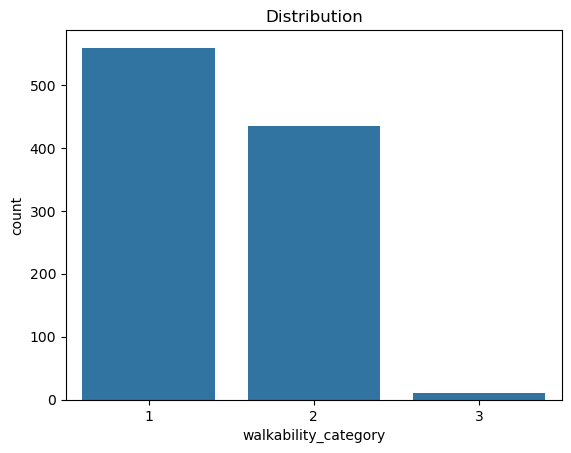

In [93]:
#distribution of target variable
sns.countplot(x=y)
plt.title("Distribution")
plt.show()

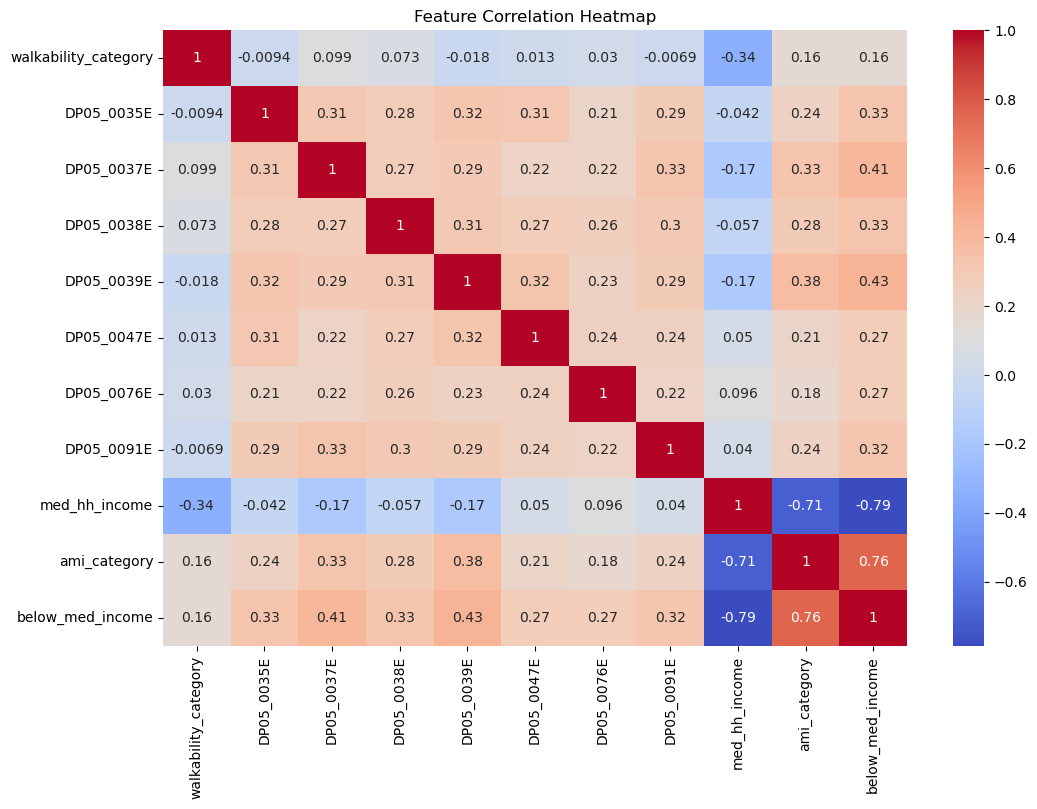

In [95]:
#dist heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(merged.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [97]:
#impute missing values
imputer = SimpleImputer(strategy='mean')  # or median, depending on your data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [99]:
#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [101]:
#smote
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [103]:
#define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state= 12),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state= 12)
}

#store results
results = []

In [105]:
#encode y to be 0-indexed
le = LabelEncoder()

#fit on combined train and test targets to preserve mapping
le.fit(np.concatenate([y_train_resampled, y_test]))

#transform both training and test labels
y_train_encoded = le.transform(y_train_resampled)
y_test_encoded = le.transform(y_test)



Logistic Regression
Accuracy: 0.4826
F1 Score (weighted): 0.5347
Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.48      0.56       112
           2       0.54      0.49      0.51        87
           3       0.00      0.00      0.00         2

    accuracy                           0.48       201
   macro avg       0.40      0.33      0.36       201
weighted avg       0.60      0.48      0.53       201



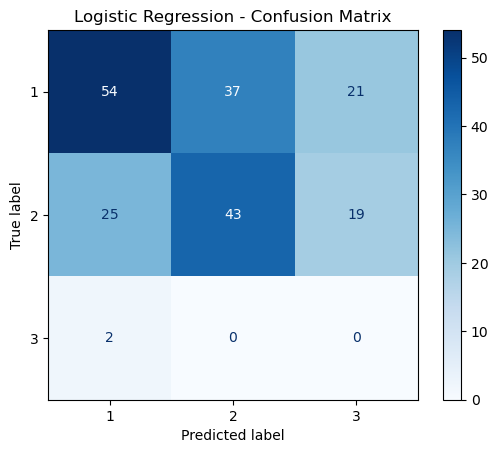


Random Forest
Accuracy: 0.5473
F1 Score (weighted): 0.5817
Classification Report:
               precision    recall  f1-score   support

           1       0.65      0.62      0.63       112
           2       0.60      0.47      0.53        87
           3       0.00      0.00      0.00         2

    accuracy                           0.55       201
   macro avg       0.42      0.36      0.39       201
weighted avg       0.62      0.55      0.58       201



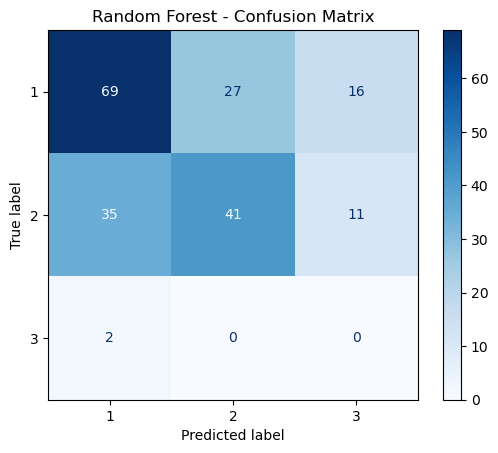


XGBoost
Accuracy: 0.5572
F1 Score (weighted): 0.5953
Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.61      0.64       112
           2       0.61      0.51      0.55        87
           3       0.00      0.00      0.00         2

    accuracy                           0.56       201
   macro avg       0.43      0.37      0.40       201
weighted avg       0.64      0.56      0.60       201



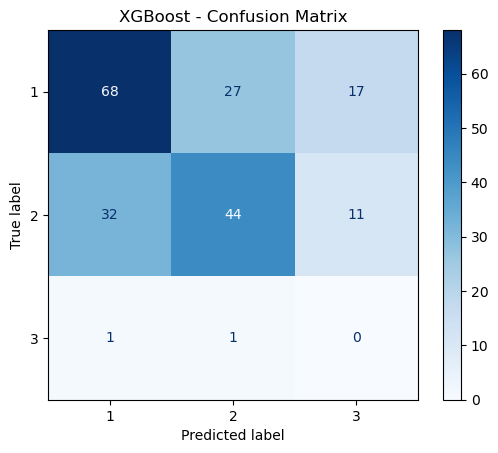

In [107]:
for name, model in models.items():
    print(f"\n{name}")

    # Fit
    if name == "XGBoost":
        model.fit(X_train_resampled, y_train_encoded)
        y_pred = model.predict(X_test_scaled)
        y_pred = le.inverse_transform(y_pred)  # Convert back to original labels for eval
    else:
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("Accuracy:", round(acc, 4))
    print("F1 Score (weighted):", round(f1, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})


In [109]:
#feature importance--  which features affect walkability the most?
importances = models["XGBoost"].feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False).head(10)


,Feature,Importance
8,ami_category,0.255185
4,DP05_0047E,0.195277
7,med_hh_income,0.123315
3,DP05_0039E,0.084999
1,DP05_0037E,0.081763
2,DP05_0038E,0.081181
0,DP05_0035E,0.065743
5,DP05_0076E,0.054450
6,DP05_0091E,0.044737
9,below_med_income,0.013350


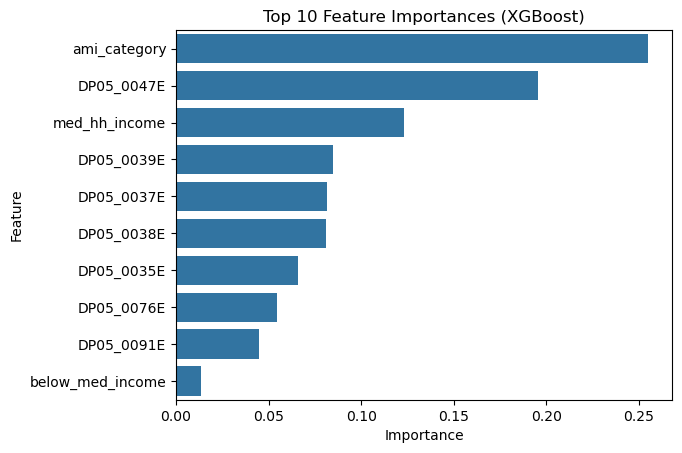

In [111]:
#plot
sns.barplot(data=importance_df.sort_values(by="Importance", ascending=False).head(10),
            x="Importance", y="Feature")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

In [ ]:
#dp05_0047E = Asians in tract

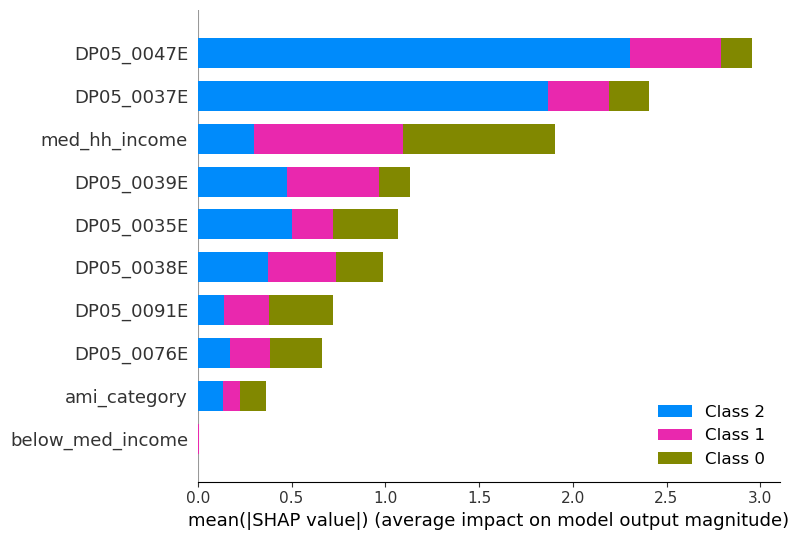

In [113]:
#shap
explainer = shap.Explainer(models["XGBoost"])
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


<Axes: xlabel='walkability_category', ylabel='med_hh_income'>

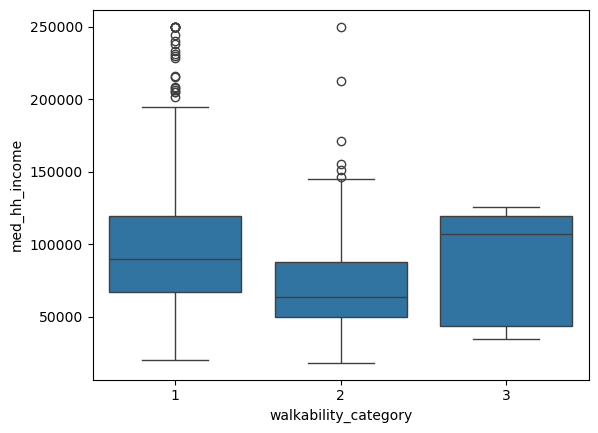

In [115]:
#what characteristics do walkable neighborhoods have in income?
merged.groupby("walkability_category").mean(numeric_only=True)

sns.boxplot(x="walkability_category", y="med_hh_income", data=merged)


In [ ]:
#i think i still need to normalize data